In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import pandas_profiling 
import datetime as dt

# 1. Merge the datasets Customers, Product Hierarchy and Transactions as Customer_Final. Ensure to keep all customers who have done transactions with us and select the join type accordingly.

In [2]:
cust = pd.read_csv("data/Customer.csv")
prod = pd.read_csv("data/prod_cat_info.csv")
tran = pd.read_csv("data/Transactions.csv")

In [3]:
cust.head()

,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.0
1,269696,07-01-1970,F,8.0
2,268159,08-01-1970,F,8.0
3,270181,10-01-1970,F,2.0
4,268073,11-01-1970,M,1.0


In [4]:
prod.head()

,prod_cat_code,prod_cat,prod_sub_cat_code,prod_subcat
0,1,Clothing,4,Mens
1,1,Clothing,1,Women
2,1,Clothing,3,Kids
3,2,Footwear,1,Mens
4,2,Footwear,3,Women


In [5]:
tran.head()

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop


In [6]:
cust = cust.rename(columns={'customer_Id':'cust_id'})

In [7]:
merged_tran_cust = pd.merge(tran,cust, on='cust_id',how='left')
customer_final = pd.merge(merged_tran_cust,prod,on='prod_cat_code',how='left')
customer_final.head()

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,4,Mens
1,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,1,Women
2,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,3,Kids
3,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,4,Mobiles
4,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,5,Computers


# 2. Prepare a summary report for the merged data set.
 a. Get the column names and their corresponding data types


In [8]:
customer_final.columns

Index(['transaction_id', 'cust_id', 'tran_date', 'prod_subcat_code',
       'prod_cat_code', 'Qty', 'Rate', 'Tax', 'total_amt', 'Store_type', 'DOB',
       'Gender', 'city_code', 'prod_cat', 'prod_sub_cat_code', 'prod_subcat'],
      dtype='object')

In [9]:
customer_final.dtypes

transaction_id         int64
cust_id                int64
tran_date             object
prod_subcat_code       int64
prod_cat_code          int64
Qty                    int64
Rate                   int64
Tax                  float64
total_amt            float64
Store_type            object
DOB                   object
Gender                object
city_code            float64
prod_cat              object
prod_sub_cat_code      int64
prod_subcat           object
dtype: object

In [10]:
customer_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99293 entries, 0 to 99292
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     99293 non-null  int64  
 1   cust_id            99293 non-null  int64  
 2   tran_date          99293 non-null  object 
 3   prod_subcat_code   99293 non-null  int64  
 4   prod_cat_code      99293 non-null  int64  
 5   Qty                99293 non-null  int64  
 6   Rate               99293 non-null  int64  
 7   Tax                99293 non-null  float64
 8   total_amt          99293 non-null  float64
 9   Store_type         99293 non-null  object 
 10  DOB                99293 non-null  object 
 11  Gender             99253 non-null  object 
 12  city_code          99257 non-null  float64
 13  prod_cat           99293 non-null  object 
 14  prod_sub_cat_code  99293 non-null  int64  
 15  prod_subcat        99293 non-null  object 
dtypes: float64(3), int64(7

### b. Top/Bottom 10 observations

In [11]:
top_10 = customer_final.head(10)
bottom_10 = customer_final.tail(10)

In [12]:
top_10

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,4,Mens
1,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,1,Women
2,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,3,Kids
3,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,4,Mobiles
4,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,5,Computers
5,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,8,Personal Appliances
6,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,9,Cameras
7,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,10,Audio and video
8,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,27-07-1992,M,8.0,Books,7,Fiction
9,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,27-07-1992,M,8.0,Books,12,Academic


In [13]:
bottom_10

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
99283,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,22-05-1970,M,2.0,Books,10,Non-Fiction
99284,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,22-05-1970,M,2.0,Books,11,Children
99285,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,22-05-1970,M,2.0,Books,3,Comics
99286,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,22-05-1970,M,2.0,Books,6,DIY
99287,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,15-01-1982,M,1.0,Books,7,Fiction
99288,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,15-01-1982,M,1.0,Books,12,Academic
99289,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,15-01-1982,M,1.0,Books,10,Non-Fiction
99290,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,15-01-1982,M,1.0,Books,11,Children
99291,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,15-01-1982,M,1.0,Books,3,Comics
99292,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,15-01-1982,M,1.0,Books,6,DIY


### c. “Five-number summary” for continuous variables (min, Q1, median, Q3 and max)

In [14]:
customer_final.head()

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,4,Mens
1,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,1,Women
2,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,3,Kids
3,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,4,Mobiles
4,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,5,Computers


In [15]:
summary = customer_final['total_amt'].describe()

In [16]:
five_number_summary = pd.DataFrame(summary)
five_number_summary

,total_amt
count,99293.000000
mean,2114.616420
std,2502.306768
min,-8270.925000
25%,762.450000
50%,1761.370000
75%,3585.725000
max,8287.500000


### d. Frequency tables for all the categorical variables

In [17]:
categorical_columns = customer_final.select_dtypes(include=['object']).columns
for column in categorical_columns:
    freq_table = customer_final[column].value_counts()
    print(f"Frequency Table for {column}:\n")
    print(freq_table)
    print("\n")

Frequency Table for tran_date:

tran_date
25-08-2012    153
13-07-2011    144
25-09-2011    144
3/2/2014      142
21-12-2013    141
             ... 
23-02-2014     11
24-02-2014     10
27-02-2014      5
21-02-2014      5
28-02-2014      3
Name: count, Length: 1129, dtype: int64


Frequency Table for Store_type:

Store_type
e-Shop            40185
MBR               19974
Flagship store    19814
TeleShop          19320
Name: count, dtype: int64


Frequency Table for DOB:

DOB
27-12-1988    156
17-09-1982    134
25-02-1974    126
18-11-1991    114
09-06-1970    107
             ... 
26-09-1983      2
09-05-1976      2
18-12-1973      2
26-02-1981      2
13-05-1981      2
Name: count, Length: 3987, dtype: int64


Frequency Table for Gender:

Gender
M    51051
F    48202
Name: count, dtype: int64


Frequency Table for prod_cat:

prod_cat
Books               36414
Electronics         24490
Home and kitchen    16516
Footwear             8997
Clothing             8880
Bags                 399

# 3. Generate histograms for all continuous variables and frequency bars for categorical variables

In [18]:
customer_final.dtypes

transaction_id         int64
cust_id                int64
tran_date             object
prod_subcat_code       int64
prod_cat_code          int64
Qty                    int64
Rate                   int64
Tax                  float64
total_amt            float64
Store_type            object
DOB                   object
Gender                object
city_code            float64
prod_cat              object
prod_sub_cat_code      int64
prod_subcat           object
dtype: object

In [19]:
continuous_variables = customer_final.select_dtypes(include=['float64','int64']).columns
categorical_variables = customer_final.select_dtypes(include=['object']).columns

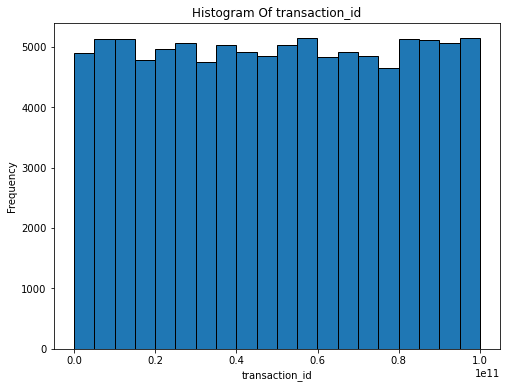

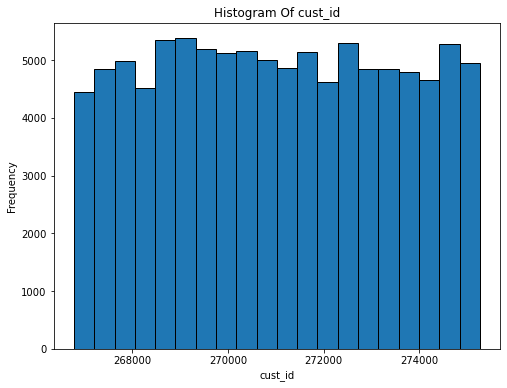

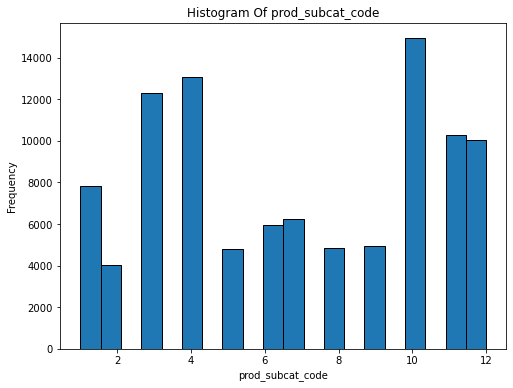

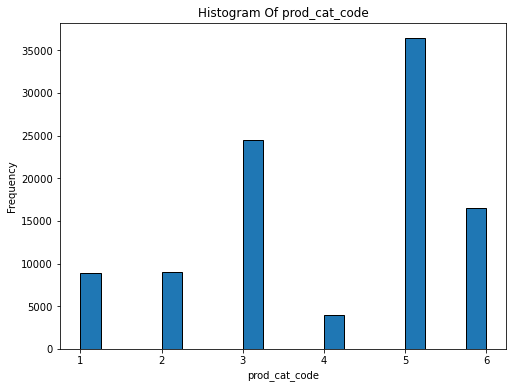

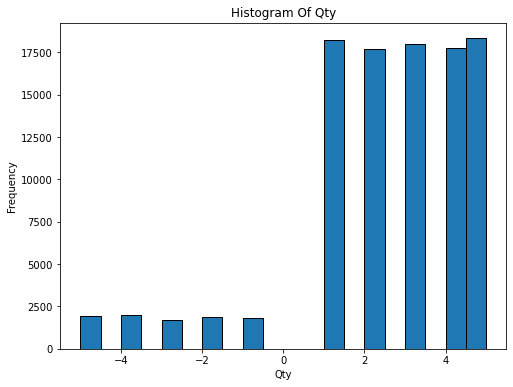

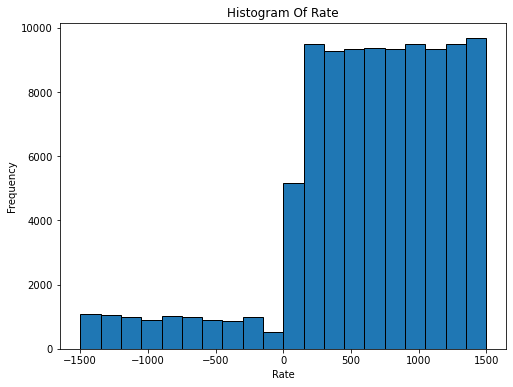

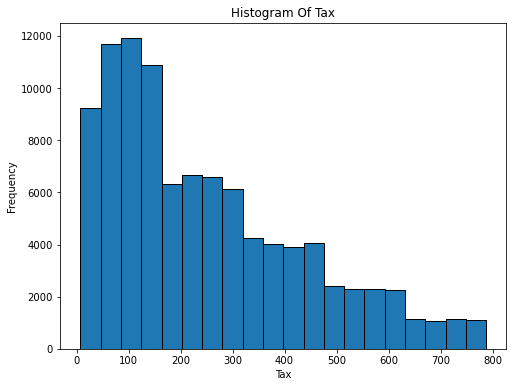

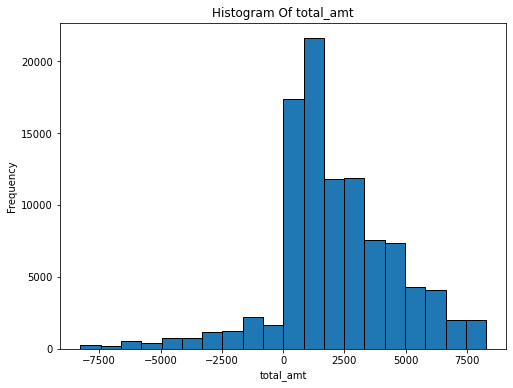

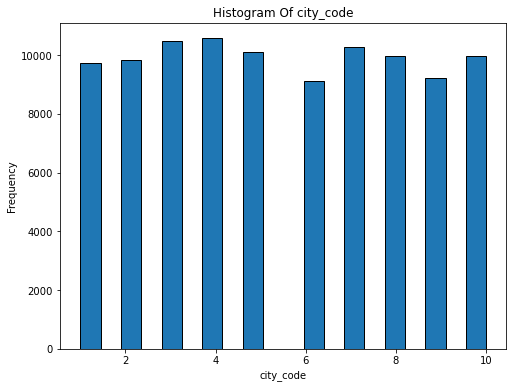

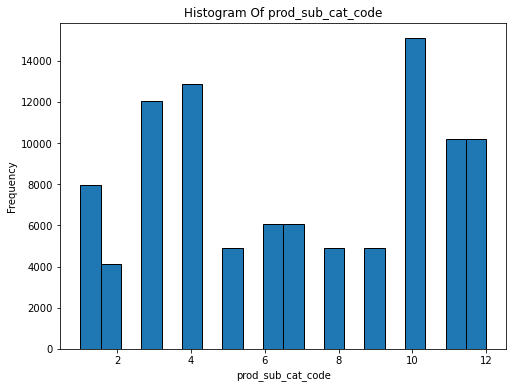

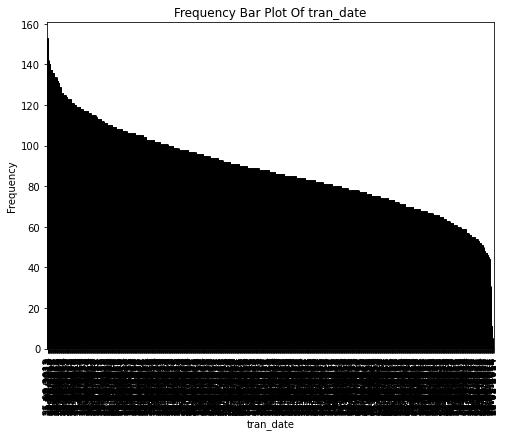

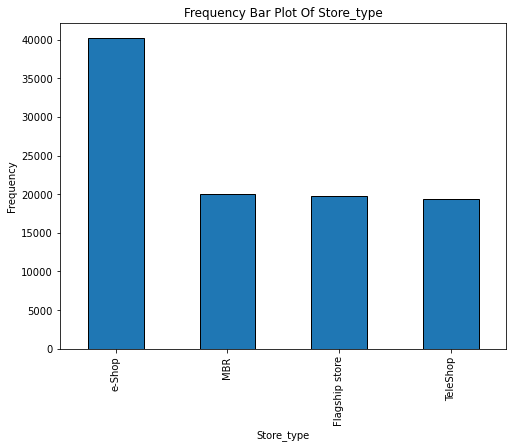

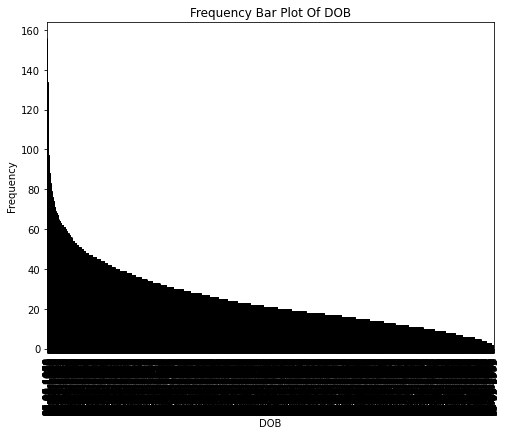

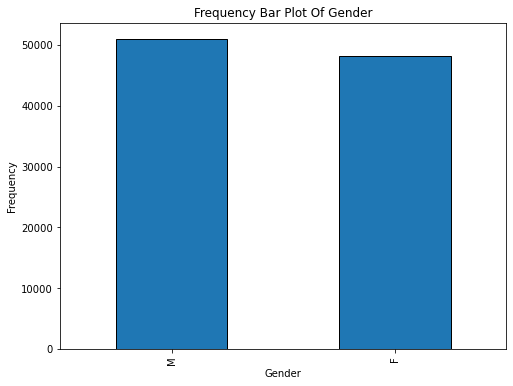

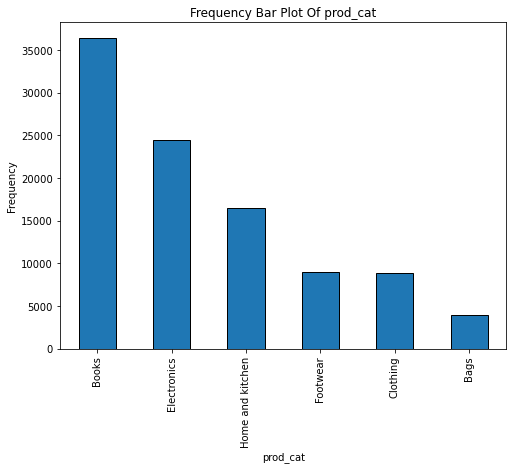

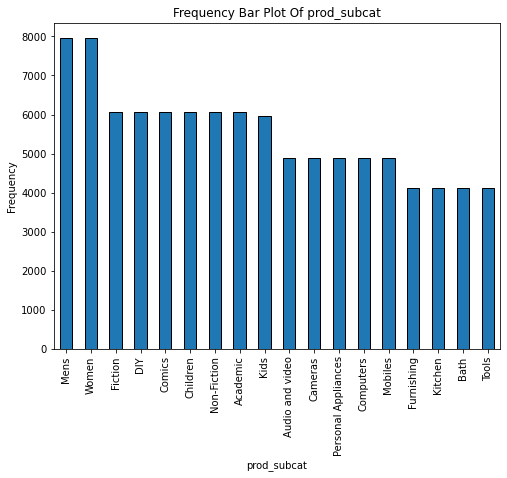

In [20]:
for column in continuous_variables:
    plt.figure(figsize=(8,6))
    plt.hist(customer_final[column], bins=20, edgecolor='k')
    plt.title(f'Histogram Of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()
    
for column in categorical_variables:
    freq_table = customer_final[column].value_counts()
    plt.figure(figsize=(8,6))
    freq_table.plot(kind='bar', edgecolor='k')
    plt.title(f'Frequency Bar Plot Of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
for column in continuous_variables:
    plt.figure(figsize=(8, 6))
    plt.hist(customer_final[column], bins=20, edgecolor='k')
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# 4. Calculate the following information using the merged dataset :
 a. Time period of the available transaction data

In [25]:
customer_final.dtypes

transaction_id                int64
cust_id                       int64
tran_date            datetime64[ns]
prod_subcat_code              int64
prod_cat_code                 int64
Qty                           int64
Rate                          int64
Tax                         float64
total_amt                   float64
Store_type                   object
DOB                          object
Gender                       object
city_code                   float64
prod_cat                     object
prod_sub_cat_code             int64
prod_subcat                  object
dtype: object

In [24]:
customer_final['tran_date'] = pd.to_datetime(customer_final['tran_date'],format='mixed')

In [40]:
customer_final['tran_date'].min()

Timestamp('2011-01-02 00:00:00')

In [27]:
customer_final['tran_date'].min()

Timestamp('2014-12-02 00:00:00')

In [43]:
customer_final['tran_date'].max() - customer_final['tran_date'].min() 

Timedelta('1430 days 00:00:00')

### b. Count of transactions where the total amount of transaction was negative

In [44]:
len(customer_final[customer_final['total_amt'] < 0])

9294

In [45]:
customer_final[customer_final['total_amt']<0]['total_amt'].count()

9294

### 5. Analyze which product categories are more popular among females vs male customers.

In [48]:
gender_purchase = customer_final.groupby(['Gender','prod_cat']).size().unstack(fill_value=0)
gender_purchase

prod_cat,Bags,Books,Clothing,Electronics,Footwear,Home and kitchen
Gender,,,,,,
F,1988,17694,4317,11640,4587,7976
M,2008,18696,4554,12850,4407,8536


In [61]:
gender_purchase.sum(axis=1)

Gender
F    48202
M    51051
dtype: int64

In [64]:
customer_final[customer_final['Gender'] == 'F'].count()

transaction_id       48202
cust_id              48202
tran_date            48202
prod_subcat_code     48202
prod_cat_code        48202
Qty                  48202
Rate                 48202
Tax                  48202
total_amt            48202
Store_type           48202
DOB                  48202
Gender               48202
city_code            48192
prod_cat             48202
prod_sub_cat_code    48202
prod_subcat          48202
dtype: int64

In [71]:
customer_final[customer_final['Gender'] == 'M'].count()

transaction_id       51051
cust_id              51051
tran_date            51051
prod_subcat_code     51051
prod_cat_code        51051
Qty                  51051
Rate                 51051
Tax                  51051
total_amt            51051
Store_type           51051
DOB                  51051
Gender               51051
city_code            51025
prod_cat             51051
prod_sub_cat_code    51051
prod_subcat          51051
dtype: int64

### 6. Which City code has the maximum customers and what was the percentage of customers from that city?


In [72]:
customer_final.columns

Index(['transaction_id', 'cust_id', 'tran_date', 'prod_subcat_code',
       'prod_cat_code', 'Qty', 'Rate', 'Tax', 'total_amt', 'Store_type', 'DOB',
       'Gender', 'city_code', 'prod_cat', 'prod_sub_cat_code', 'prod_subcat'],
      dtype='object')

In [88]:
c1 = customer_final['city_code'].max()

In [89]:
c2 = customer_final['city_code'].count()

In [90]:
c1/c2 * 100

0.010074856181428012

In [92]:
customer_final['city_code'].value_counts()

city_code
4.0     10571
3.0     10467
7.0     10258
5.0     10116
10.0     9976
8.0      9965
2.0      9843
1.0      9717
9.0      9214
6.0      9130
Name: count, dtype: int64

### 7. Which store type sells the maximum products by value and by quantity?

In [98]:
customer_final.groupby(['Store_type','Qty']).size().unstack(fill_value=0)

Qty,-5,-4,-3,-2,-1,1,2,3,4,5
Store_type,,,,,,,,,,
Flagship store,396,372,406,383,326,3640,3403,3835,3431,3622
MBR,489,353,293,385,378,3690,3635,3407,3732,3612
TeleShop,301,396,331,395,305,3556,3641,3488,3321,3586
e-Shop,726,858,693,719,789,7331,7011,7287,7254,7517


In [96]:
customer_final.groupby('Store_type').agg({'total_amt': 'sum', 'Qty': 'sum'})

,total_amt,Qty
Store_type,,
Flagship store,4.188397e+07,48007
MBR,4.170033e+07,48285
TeleShop,4.046656e+07,47339
e-Shop,8.591575e+07,98447


### 8. What was the total amount earned from the "Electronics" and "Clothing" categories from Flagship Stores?


In [105]:
customer_final[customer_final['Store_type'] == 'Flagship store']

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
81,25963520987,274829,2014-02-20,4,4,3,502,158.130,1664.130,Flagship store,05-09-1984,F,2.0,Bags,1,Mens
82,25963520987,274829,2014-02-20,4,4,3,502,158.130,1664.130,Flagship store,05-09-1984,F,2.0,Bags,4,Women
130,99581788104,267466,2014-02-20,3,2,1,96,10.080,106.080,Flagship store,06-08-1987,F,7.0,Footwear,1,Mens
131,99581788104,267466,2014-02-20,3,2,1,96,10.080,106.080,Flagship store,06-08-1987,F,7.0,Footwear,3,Women
132,99581788104,267466,2014-02-20,3,2,1,96,10.080,106.080,Flagship store,06-08-1987,F,7.0,Footwear,4,Kids
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99205,32887353269,268885,2011-01-25,3,1,1,276,28.980,304.980,Flagship store,14-04-1989,F,6.0,Clothing,1,Women
99206,32887353269,268885,2011-01-25,3,1,1,276,28.980,304.980,Flagship store,14-04-1989,F,6.0,Clothing,3,Kids
99229,62511551321,270394,2011-01-25,3,2,5,631,331.275,3486.275,Flagship store,28-04-1978,F,9.0,Footwear,1,Mens
99230,62511551321,270394,2011-01-25,3,2,5,631,331.275,3486.275,Flagship store,28-04-1978,F,9.0,Footwear,3,Women


In [107]:
fs = customer_final[customer_final['Store_type'] == 'Flagship store']
fs_e = fs[fs['prod_cat']=="Electronics"]
fs_c = fs[fs['prod_cat']=="Clothing"]
fs_e_sum_value = fs_e['total_amt'].sum()
fs_c_sum_value = fs_c['total_amt'].sum()
total_value_from_e_c = fs_c_sum_value + fs_e_sum_value
print("Total Amount Earned from Electronics and Clothing Categories at Flagship Stores:", total_value_from_e_c)

Total Amount Earned from Electronics and Clothing Categories at Flagship Stores: 14658949.889999999


### 9. What was the total amount earned from "Male" customers under the"Electronics" category?

In [111]:
mc = customer_final[customer_final['Gender'] == 'M']
mc_e = mc[mc['prod_cat']=="Electronics"]
mc_total = mc_e['total_amt'].sum()
print("Total Amount Earned from Male Customer under the Electronics category is :", mc_total)

Total Amount Earned from Male Customer under the Electronics category is : 28515547.125


### 10. How many customers have more than 10 unique transactions, after removing all transactions which have any negative amounts?


In [123]:
ta = customer_final[customer_final['total_amt']>=0]
uni_ta = ta.groupby('cust_id')['transaction_id'].nunique()
cust_uni_ta = (uni_ta > 10).sum()
print('Number of Customer with more than 10 unique transaction are:',cust_uni_ta)

Number of Customer with more than 10 unique transaction are: 6


### 11. For all customers aged between 25 - 35, find out:
 a. What was the total amount spent for “Electronics” and “Books” product categories?

In [132]:
customer_final['DOB'] = pd.to_datetime(customer_final['DOB'], format='mixed')
current_date = dt.datetime.now()
customer_final['Age'] = (current_date - customer_final['DOB']).dt.days // 365
customer_final.head()

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat,Age
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5.0,Clothing,4,Mens,41
1,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5.0,Clothing,1,Women,41
2,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5.0,Clothing,3,Kids,41
3,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,1973-11-05,F,8.0,Electronics,4,Mobiles,49
4,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,1973-11-05,F,8.0,Electronics,5,Computers,49


In [141]:
cust_25_35 = customer_final[(customer_final['Age']>= 25) & (customer_final['Age']<= 35)]
cust_25_35_e = cust_25_35[cust_25_35['prod_cat'] == 'Electronics']
cust_25_35_b = cust_25_35[cust_25_35['prod_cat'] == 'Books']
te = cust_25_35_e['total_amt'].sum()
tb = cust_25_35_b['total_amt'].sum()
total_cust_25_35 =te+tb
print('For the customers aged between 25 - 35, the total amount spent for “Electronics” and “Books” product categories is:', total_cust_25_35)

For the customers aged between 25 - 35, the total amount spent for “Electronics” and “Books” product categories is: 29105044.735


### b. What was the total amount spent by these customers between 1st Jan, 2014 to 1st Mar, 2014?

In [146]:
start_date_e = pd.Timestamp('2014-01-01')
end_date_e = pd.Timestamp('2014-03-01')
fd_e = cust_25_35_e[(cust_25_35_e['tran_date']>= start_date_e) & (cust_25_35_e['tran_date']<= end_date_e)]
tase = fd_e['total_amt'].sum()
tase

352119.3000000001

In [147]:
start_date_b = pd.Timestamp('2014-01-01')
end_date_b = pd.Timestamp('2014-03-01')
fd_b = cust_25_35_b[(cust_25_35_b['tran_date']>= start_date_e) & (cust_25_35_b['tran_date']<= end_date_b)]
tasb = fd_b['total_amt'].sum()
tasb

562986.4500000001

In [149]:
total_amount_spent = tase + tasb
total_amount_spent

915105.7500000002

In [151]:
print('The total amount spent by these customers between 1st Jan 2014 to 1st Mar 2014 is:',total_amount_spent)

The total amount spent by these customers between 1st Jan 2014 to 1st Mar 2014 is: 915105.7500000002
